# Aquila Optimizer (AO) dengan Multi-Objective & Constraints (Pareto Front)
Notebook ini mengimplementasikan pemodelan optimasi matematika logistik yang lebih **realistis** dengan memperkenalkan:
1. **Hard Capacity Constraints**: Batasan kapasitas maksimum armada (misal *First Class* dan *Same Day* tidak bisa mendominasi 100% pengiriman).
2. **Multi-Objective Weights**: Pembobotan pada fungsi biaya (Fokus Penghematan vs Fokus Ketepatan Waktu).
3. **Pareto Front Analysis**: Melihat *trade-off* antara Transport Cost vs Penalty (Delay & Degradation) pada berbagai skenario.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gamma
import math

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Parameter & Constraints Setup
Data historis menggunakan 4 jenis moda pengiriman utama:
1. **Standard Class** (Biaya rendah, Risiko keterlambatan tinggi, Risiko degradasi suhu tinggi)
2. **Second Class** (Biaya menengah, Risiko sedang)
3. **First Class** (Biaya mahal, Risiko rendah)
4. **Same Day** (Biaya sangat mahal, Risiko sangat rendah)


In [2]:
# Parameter Cost (Mata Uang/Unit)
c_trans = np.array([10, 30, 50, 80])       # Transport Cost (Standard, Second, First, Same Day)
p_delay = np.array([0.4, 0.2, 0.05, 0.01]) # Peluang Keterlambatan
p_deg = np.array([0.3, 0.15, 0.05, 0.01])  # Peluang Kerusakan karena Suhu

penalty_delay = 100
penalty_deg = 150

# Target Rata-rata Prediksi GRU (contoh dari Test Set)
predicted_demand = 385  # unit pesanan harian

# Naive Historical Distribution (Standard, Second, First, Same Day)
historical_dist = np.array([0.60, 0.20, 0.15, 0.05])

# Hard Capacity Constraints (Maksimum Alokasi Persentase)
max_capacity = np.array([1.0, 0.40, 0.20, 0.05]) # Standard Class tak terbatas
min_capacity = np.array([0.35, 0.0, 0.0, 0.0])   # Minimal Standard 35% agar armada massal jalan


## 2. Multi-Objective Function (Fitness) dengan Penalty Method
Menghitung total biaya berdasarkan proporsi alokasi $x$. 
Jika AO mencoba memberikan solusi yang melanggar batas kapasitas, fungsi ini akan memberikan **Penalti Ekstrem** sehingga AO menjauhinya.


In [3]:
def objective_function(x, w1=1/3, w2=1/3, w3=1/3):
    # Constraint handling: Normalisasi x agar jumlahnya 1 (100% Demand Fulfillment)
    x = np.abs(x)
    sum_x = np.sum(x)
    if sum_x == 0:
        x = np.ones(len(x)) / len(x)
    else:
        x = x / sum_x
        
    # Penalty Method for Capacity Constraints
    constraint_penalty = 0
    for i in range(len(x)):
        if x[i] > max_capacity[i]:
            constraint_penalty += (x[i] - max_capacity[i]) * 1000000  # Penalti masif
        if x[i] < min_capacity[i]:
            constraint_penalty += (min_capacity[i] - x[i]) * 1000000
    
    # Menghitung komponen biaya murni
    cost_trans = predicted_demand * np.sum(x * c_trans)
    cost_delay = predicted_demand * np.sum(x * p_delay * penalty_delay)
    cost_deg = predicted_demand * np.sum(x * p_deg * penalty_deg)
    
    # Weighted Multi-Objective Fitness (Ditambah penalty constraint jika ada)
    # Z = w1 * Trans + w2 * Delay + w3 * Deg
    Z = (w1 * cost_trans) + (w2 * cost_delay) + (w3 * cost_deg) + constraint_penalty
    
    return Z, cost_trans, cost_delay, cost_deg, x


## 3. Algoritma Aquila Optimizer (AO)
Diimplementasikan secara *from-scratch* berdasarkan paper Abualigah et al. (2021).


In [4]:
def levy_flight(dim):
    beta = 1.5
    sigma = (gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    step = u / abs(v)**(1 / beta)
    return step

def aquila_optimizer(w1, w2, w3, dim=4, lb=0.001, ub=1, max_iter=100, pop_size=30):
    # Inisialisasi Populasi
    X = np.random.uniform(lb, ub, (pop_size, dim))
    best_X = np.zeros(dim)
    best_fitness = float('inf')
    
    alpha = 0.1
    delta = 0.1
    
    for t in range(max_iter):
        X_mean = np.mean(X, axis=0)
        for i in range(pop_size):
            r1 = np.random.rand()
            if t <= (2/3) * max_iter:
                if np.random.rand() < 0.5:
                    X[i] = best_X * (1 - t / max_iter) + (X_mean - best_X) * np.random.rand()
                else:
                    levy = levy_flight(dim)
                    X[i] = best_X * levy + X[i] + (np.random.rand() * (ub - lb) + lb)
            else:
                if np.random.rand() < 0.5:
                    X[i] = (best_X - X_mean) * alpha - np.random.rand() + ((ub - lb) * np.random.rand() + lb) * delta
                else:
                    QF = t ** ((2 * np.random.rand() - 1) / (1 - max_iter)**2)
                    G1 = 2 * np.random.rand() - 1
                    G2 = 2 * (1 - t / max_iter)
                    X[i] = QF * best_X - (G1 * X[i] * np.random.rand()) - G2 * levy_flight(dim) + np.random.rand() * G1
            
            X[i] = np.clip(X[i], lb, ub)
            
            # Hitung Fitness (Ambil output ke-0 yaitu Z)
            new_fitness = objective_function(X[i], w1, w2, w3)[0]
            if new_fitness < best_fitness:
                best_fitness = new_fitness
                best_X = X[i].copy()
                
    # Retrive Final Results for Best Solution
    Z, c_trans, c_delay, c_deg, final_x = objective_function(best_X, w1, w2, w3)
    return final_x, c_trans, c_delay, c_deg


## 4. Analisis Pareto Front (Trade-off)
Kita membuat tiga skenario (Cost-Centric, Balanced, Quality-Centric) untuk melihat distribusi terbaik yang dihasilkan AO tanpa mendominasi 100% pada satu opsi armada.


In [5]:
# Menyimpan hasil
scenarios = [
    {"name": "Historical", "w": None, "results": None},
    {"name": "Cost-Centric", "w": (0.8, 0.1, 0.1), "results": None},
    {"name": "Balanced", "w": (0.33, 0.33, 0.33), "results": None},
    {"name": "Quality-Centric", "w": (0.1, 0.45, 0.45), "results": None}
]

# Run Historical Skenario
_, h_trans, h_delay, h_deg, h_x = objective_function(historical_dist, 1, 1, 1)
scenarios[0]["results"] = (h_x, h_trans, h_delay, h_deg)

print("--- Menjalankan Optimasi Skenario (AO Multiple Runs) ---")
for s in scenarios[1:]:
    w1, w2, w3 = s["w"]
    final_x, trans, delay, deg = aquila_optimizer(w1, w2, w3, max_iter=200, pop_size=50)
    s["results"] = (final_x, trans, delay, deg)
    print(f"Selesai Skenario: {s['name']}")


--- Menjalankan Optimasi Skenario (AO Multiple Runs) ---


Selesai Skenario: Cost-Centric


Selesai Skenario: Balanced


Selesai Skenario: Quality-Centric


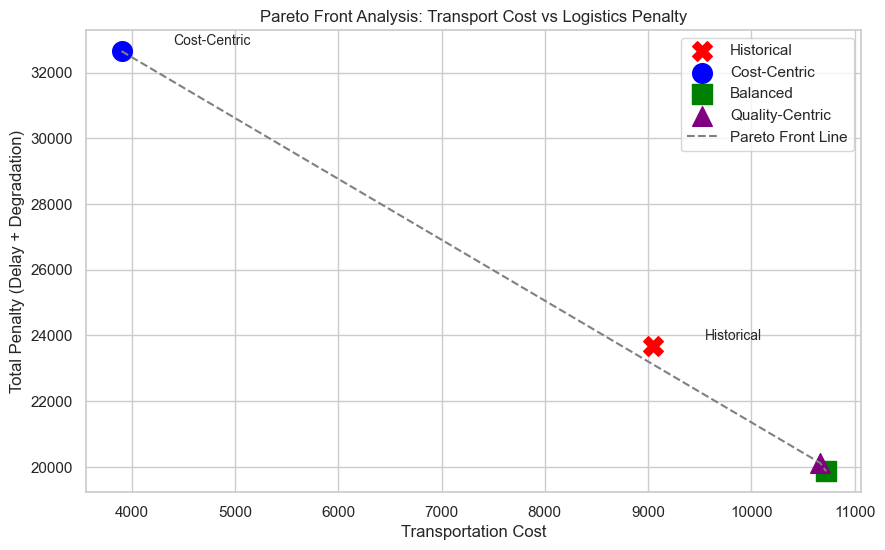

In [6]:
# Extract Data for Plotting
names = [s["name"] for s in scenarios]
trans_costs = [s["results"][1] for s in scenarios]
penalties = [s["results"][2] + s["results"][3] for s in scenarios]  # Total Penalty (Delay + Deg)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'purple']
markers = ['X', 'o', 's', '^']

for i in range(len(scenarios)):
    ax.scatter(trans_costs[i], penalties[i], label=names[i], color=colors[i], marker=markers[i], s=200)

# Connect Optimizations Points for Pareto Curve (Excluding Historical)
sort_idx = np.argsort(trans_costs[1:])
pareto_x = np.array(trans_costs[1:])[sort_idx]
pareto_y = np.array(penalties[1:])[sort_idx]
ax.plot(pareto_x, pareto_y, linestyle='--', color='gray', label='Pareto Front Line')

# Annotation
for i, name in enumerate(names):
    ax.annotate(name, (trans_costs[i]+500, penalties[i]+200), fontsize=10)

ax.set_title('Pareto Front Analysis: Transport Cost vs Logistics Penalty')
ax.set_xlabel('Transportation Cost')
ax.set_ylabel('Total Penalty (Delay + Degradation)')
ax.legend()
plt.grid(True)
plt.show()


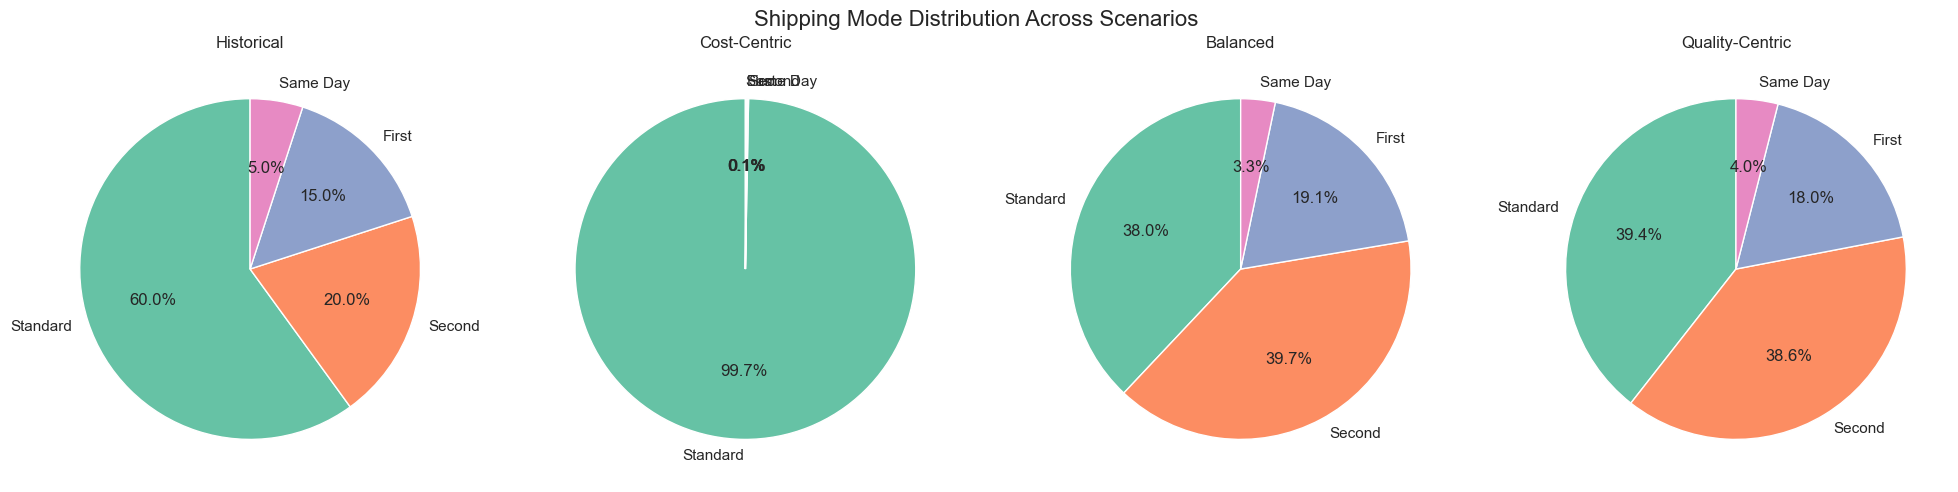

In [7]:
# Tampilkan Distribusi Optimal untuk masing-masing skenario
modes = ['Standard', 'Second', 'First', 'Same Day']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, ax in enumerate(axes):
    dist = scenarios[i]["results"][0]
    ax.pie(dist, labels=modes, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
    ax.set_title(scenarios[i]["name"])

plt.suptitle('Shipping Mode Distribution Across Scenarios', fontsize=16)
plt.tight_layout()
plt.show()
